In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt, maximum_filter
from scipy.interpolate import UnivariateSpline
from scipy.spatial import cKDTree
import os
import pandas as pd


In [12]:
import numpy as np

data = np.load("/Users/administrateur/Desktop/projects_repo/dossier sans titre/real_data/positif/real_data_00021.npz")

print(data.files)  # shows array names inside


['data']


In [13]:
array = data.files[0]  
array_sample = data[array]  # access the array using its name
print(array_sample.shape)
print(array_sample.dtype)

(1010, 1170, 4)
float16


In [14]:
test=data[array]
rows = np.any(~np.isnan(test), axis=1)
cols = np.any(~np.isnan(test), axis=0)

rmin, rmax = np.where(rows)[0][[0, -1]]
cmin, cmax = np.where(cols)[0][[0, -1]]

cropped = test[rmin:rmax+1, cmin:cmax+1]
# Use the blue channel
img = cropped[:, :, 1]

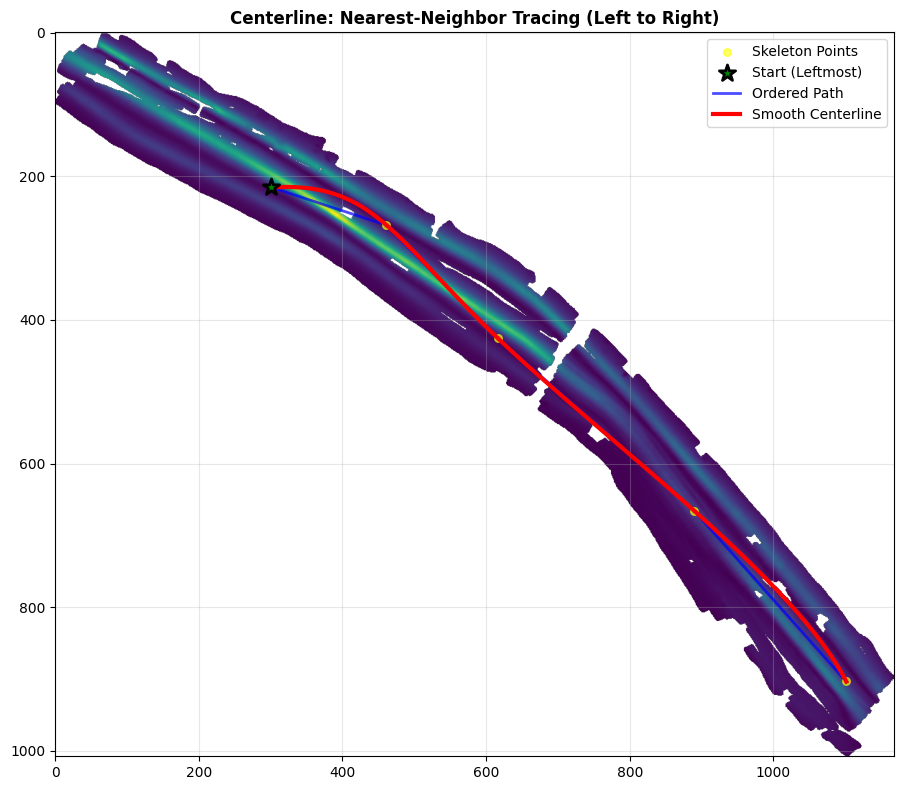

In [15]:
def create_centerline(img, max_filter_size=100, visualize=False):
   
    # Extract skeleton points
    img_mask = ~np.isnan(img)
    dist = distance_transform_edt(img_mask)
    
    # Check if image is square or nearly square (aspect ratio close to 1)
    h, w = img.shape
    aspect_ratio = max(h, w) / min(h, w)
    is_square = aspect_ratio < 1.2  # If aspect ratio is less than 1.3, treat as square
    
    if is_square and h <1000:
        print(f"Square/nearly-square image detected (aspect ratio: {aspect_ratio:.2f})")
        # For square images, use a much smaller filter to get edge points instead of center dot
        max_filter_size = max(1, min(h, w) // 8)
        if max_filter_size % 2 == 0:
            max_filter_size = 3
        print(f"Adjusted filter size for square image: {max_filter_size}")
    else:
        # Ensure filter size is odd
        
        if max_filter_size % 2 == 0:
            max_filter_size += 1
    
    skeleton_mask = (dist > 0) & img_mask & (dist == maximum_filter(dist, size=max_filter_size))
    ys_skel, xs_skel = np.where(skeleton_mask)
    
    #print(f"Skeleton points: {len(xs_skel)}")
    
    result = {
        'xs_smooth': np.array([]),
        'ys_smooth': np.array([]),
        'xs_ordered': np.array([]),
        'ys_ordered': np.array([]),
        'xs_skel': xs_skel,
        'ys_skel': ys_skel,
        'success': False
    }
    
    if len(xs_skel) <= 2:
        print("ERROR: Not enough skeleton points")
        return result
    
    # Order skeleton points using nearest-neighbor with KDTree
    points = np.column_stack([xs_skel, ys_skel])
    tree = cKDTree(points)
    
    # Start from leftmost point
    start_idx = np.argmin(xs_skel)
    ordered = [points[start_idx]]
    visited = {start_idx}
    
    # Greedily connect nearest unvisited neighbors
    while len(visited) < len(points):
        current = ordered[-1]
        _, unvisited_idx = tree.query(current, k=len(points))
        for idx in unvisited_idx:
            if idx not in visited:
                ordered.append(points[idx])
                visited.add(idx)
                break
    
    ordered = np.array(ordered)
    xs_ordered = ordered[:, 0]
    ys_ordered = ordered[:, 1]
    
    # Smooth the centerline
    try:
        t = np.linspace(0, 1, len(ordered))
        spl_x = UnivariateSpline(t, xs_ordered, s=15, k=min(3, len(ordered)-1))
        spl_y = UnivariateSpline(t, ys_ordered, s=15, k=min(3, len(ordered)-1))
        t_smooth = np.linspace(0, 1, 300)
        xs_smooth = spl_x(t_smooth)
        ys_smooth = spl_y(t_smooth)
    except:
        xs_smooth = xs_ordered
        ys_smooth = ys_ordered
    
    # Update result dictionary
    result['xs_smooth'] = xs_smooth
    result['ys_smooth'] = ys_smooth
    result['xs_ordered'] = xs_ordered
    result['ys_ordered'] = ys_ordered
    result['success'] = True
    
    # Visualization if requested
    if visualize:
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.imshow(img, cmap='viridis')
        ax.scatter(xs_skel, ys_skel, c='yellow', s=30, alpha=0.6, label='Skeleton Points', zorder=3)
        ax.scatter([xs_skel[start_idx]], [ys_skel[start_idx]], c='green', s=150, marker='*', 
                   label='Start (Leftmost)', zorder=5, edgecolors='black', linewidths=2)
        ax.plot(xs_ordered, ys_ordered, 'b-', linewidth=2, label='Ordered Path', alpha=0.7, zorder=2)
        ax.plot(xs_smooth, ys_smooth, 'r-', linewidth=3, label='Smooth Centerline', zorder=4)
        ax.set_title('Centerline: Nearest-Neighbor Tracing (Left to Right)', fontweight='bold', fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    #print(f"✓ Centerline traced starting from leftmost point (x={xs_skel[start_idx]:.0f})")
    #print(f"✓ Smooth centerline: {len(xs_smooth)} points")
    
    return result

# Calculate max_filter_size as 1/5 of the height of the scan
max_filter_size = max(1, int(img.shape[0] / 5))
# Example usage: create centerline with visualization
centerline = create_centerline(img, max_filter_size=max_filter_size, visualize=True)
# Access the smooth centerline
xs_smooth = centerline['xs_smooth']
ys_smooth = centerline['ys_smooth']

# locate the pipe approx location

Total pixels: 1177344
Valid pixels: 190172
Valid values after cleaning: 190172
Data type: float16
Min: 0.0006175041198730469, Max: 1132.0
Contains inf: False
Threshold: 190.6250


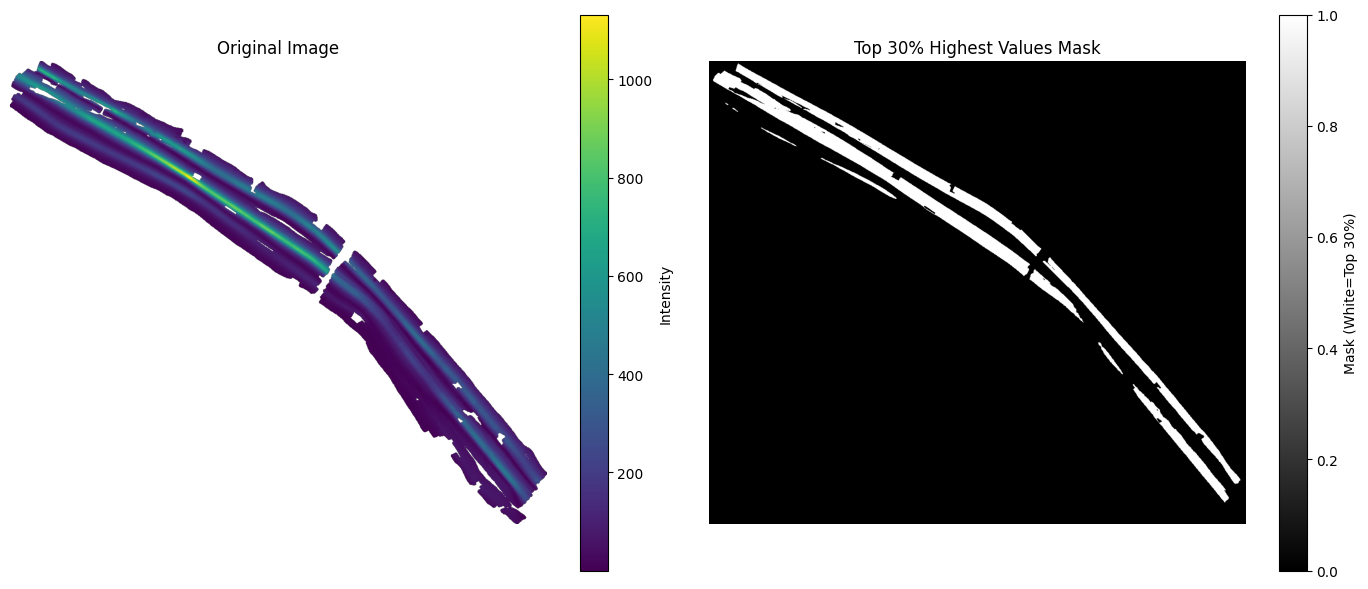

Threshold value (70th percentile): 190.6250
Number of pixels in top 30%: 57061
Percentage of image covered: 30.00%


In [16]:

# Get valid (non-NaN) values
valid_mask = ~np.isnan(img)
valid_values = img[valid_mask]

# Remove any remaining NaN values (in case there are edge cases)
valid_values = valid_values[~np.isnan(valid_values)]

print(f"Total pixels: {img.size}")
print(f"Valid pixels: {np.sum(valid_mask)}")
print(f"Valid values after cleaning: {valid_values.size}")
print(f"Data type: {valid_values.dtype}")
print(f"Min: {np.nanmin(valid_values)}, Max: {np.nanmax(valid_values)}")
print(f"Contains inf: {np.any(np.isinf(valid_values))}")

# Convert to float64 to avoid issues
valid_values = valid_values.astype(np.float64)

# Calculate the 70th percentile (top 30% of values)
if valid_values.size > 0:
    threshold = np.percentile(valid_values, 70)
    print(f"Threshold: {threshold:.4f}")
    
    # Create mask for the top 30% highest values (only among valid pixels)
    top_30_mask = (img >= threshold) & valid_mask
    
    # Create a figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Display original image
    im1 = axes[0].imshow(img, cmap='viridis')
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    plt.colorbar(im1, ax=axes[0], label='Intensity')
    
    # Display the mask (top 30%)
    im2 = axes[1].imshow(top_30_mask, cmap='gray')
    axes[1].set_title('Top 30% Highest Values Mask')
    axes[1].axis('off')
    plt.colorbar(im2, ax=axes[1], label='Mask (White=Top 30%)')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"Threshold value (70th percentile): {threshold:.4f}")
    print(f"Number of pixels in top 30%: {np.sum(top_30_mask)}")
    print(f"Percentage of image covered: {100 * np.sum(top_30_mask) / np.sum(valid_mask):.2f}%")
else:
    print("No valid values found in the image!")

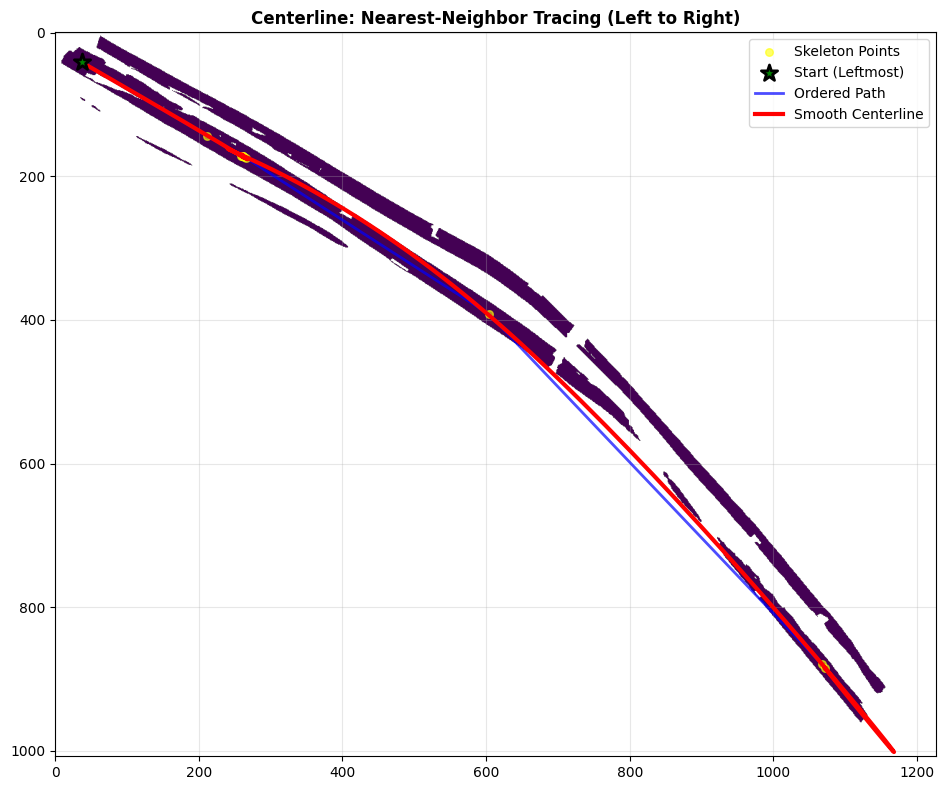


Centerline created successfully from top 30% mask
Smooth centerline points: 300


In [17]:
# Apply centerline creation to the mask (top 30%)
# Convert boolean mask to float, with NaN where mask is False
mask_for_centerline = np.where(top_30_mask, 1.0, np.nan)

# Calculate max_filter_size based on mask dimensions
max_filter_size_mask = max(1, int(mask_for_centerline.shape[0] / 5))

# Create centerline from the mask
centerline_mask = create_centerline(mask_for_centerline, max_filter_size=max_filter_size_mask, visualize=True)

# Access the smooth centerline
xs_smooth_mask = centerline_mask['xs_smooth']
ys_smooth_mask = centerline_mask['ys_smooth']

print(f"\nCenterline created successfully from top 30% mask")
print(f"Smooth centerline points: {len(xs_smooth_mask)}")

# Compare the pipe location to the centerline of the scan

/var/folders/cs/m8mz50c16l94vkqq4l0n4qhw0000gn/T/ipykernel_23721/1497260923.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


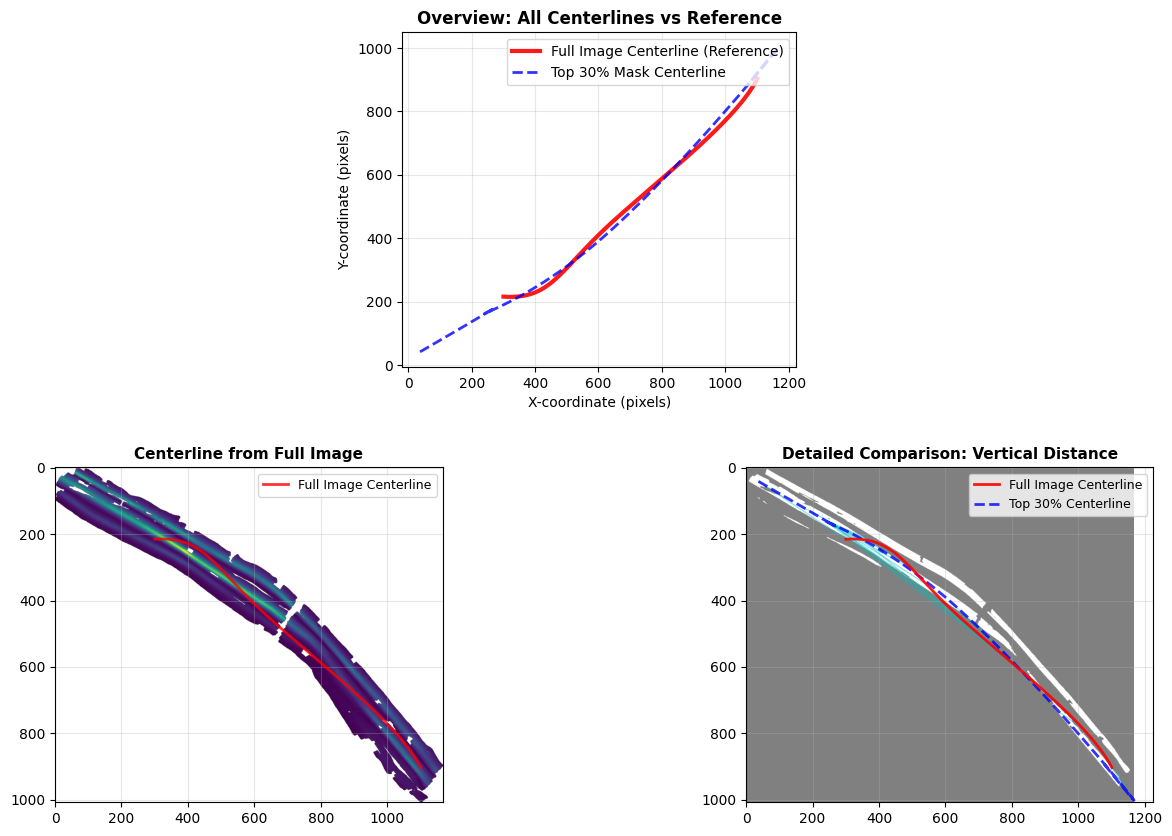

CENTERLINE COMPARISON ANALYSIS
Full Image Centerline points: 300
Top 30% Mask Centerline points: 300
Comparison points (resampled): 300

--- Distance Statistics ---
  Mean distance: 342.10 pixels
  Std deviation: 192.43 pixels
  Min distance: 14.04 pixels
  Max distance: 715.95 pixels

--- Vertical Distance Statistics ---
  Mean vertical distance: 199.20 pixels
  Std vertical distance: 126.44 pixels
  Max vertical distance: 442.58 pixels

--- Alignment Score ---
  Points within 5px: 0.0%


In [20]:
# Create figure with two subplots: overview and detailed comparison
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Plot 1: Overview - All centerlines vs reference
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(xs_smooth, ys_smooth, 'r-', linewidth=3, label='Full Image Centerline (Reference)', alpha=0.9)
ax1.plot(xs_smooth_mask, ys_smooth_mask, 'b--', linewidth=2, label='Top 30% Mask Centerline', alpha=0.8)
ax1.set_title('Overview: All Centerlines vs Reference', fontweight='bold', fontsize=12)
ax1.set_xlabel('X-coordinate (pixels)', fontsize=10)
ax1.set_ylabel('Y-coordinate (pixels)', fontsize=10)
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')

# Plot 2: Original image with centerline
ax2 = fig.add_subplot(gs[1, 0])
ax2.imshow(img, cmap='viridis')
ax2.plot(xs_smooth, ys_smooth, 'r-', linewidth=2, label='Full Image Centerline', alpha=0.8)
ax2.set_title('Centerline from Full Image', fontweight='bold', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot 3: Top 30% mask with detailed comparison
ax3 = fig.add_subplot(gs[1, 1])

# Calculate vertical distances for better visualization
# Resample both centerlines to same number of points for fair comparison
min_len = min(len(xs_smooth), len(xs_smooth_mask))
xs_smooth_resampled = np.interp(np.linspace(0, 1, min_len), 
                                np.linspace(0, 1, len(xs_smooth)), xs_smooth)
ys_smooth_resampled = np.interp(np.linspace(0, 1, min_len), 
                                np.linspace(0, 1, len(ys_smooth)), ys_smooth)
xs_mask_resampled = np.interp(np.linspace(0, 1, min_len), 
                              np.linspace(0, 1, len(xs_smooth_mask)), xs_smooth_mask)
ys_mask_resampled = np.interp(np.linspace(0, 1, min_len), 
                              np.linspace(0, 1, len(ys_smooth_mask)), ys_smooth_mask)

# Calculate vertical distances
vertical_distances = np.abs(ys_smooth_resampled - ys_mask_resampled)

# Plot the mask as background
ax3.imshow(top_30_mask, cmap='gray', alpha=0.5)

# Plot both centerlines
ax3.plot(xs_smooth_resampled, ys_smooth_resampled, 'r-', linewidth=2, 
         label='Full Image Centerline', alpha=0.9, zorder=3)
ax3.plot(xs_mask_resampled, ys_mask_resampled, 'b--', linewidth=2, 
         label='Top 30% Centerline', alpha=0.8, zorder=2)

# Draw vertical distance indicators
for i in range(0, min_len, max(1, min_len//15)):
    ax3.plot([xs_smooth_resampled[i], xs_mask_resampled[i]], 
             [ys_smooth_resampled[i], ys_mask_resampled[i]], 
             'c-', alpha=0.4, linewidth=1, zorder=1)

ax3.set_title('Detailed Comparison: Vertical Distance', fontweight='bold', fontsize=11)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate detailed statistics
print("=" * 60)
print("CENTERLINE COMPARISON ANALYSIS")
print("=" * 60)
print(f"Full Image Centerline points: {len(xs_smooth)}")
print(f"Top 30% Mask Centerline points: {len(xs_smooth_mask)}")
print(f"Comparison points (resampled): {min_len}")

# Calculate distances
distances = np.sqrt((xs_smooth_resampled - xs_mask_resampled)**2 + 
                   (ys_smooth_resampled - ys_mask_resampled)**2)

print(f"\n--- Distance Statistics ---")
print(f"  Mean distance: {np.mean(distances):.2f} pixels")
print(f"  Std deviation: {np.std(distances):.2f} pixels")
print(f"  Min distance: {np.min(distances):.2f} pixels")
print(f"  Max distance: {np.max(distances):.2f} pixels")

print(f"\n--- Vertical Distance Statistics ---")
print(f"  Mean vertical distance: {np.mean(vertical_distances):.2f} pixels")
print(f"  Std vertical distance: {np.std(vertical_distances):.2f} pixels")
print(f"  Max vertical distance: {np.max(vertical_distances):.2f} pixels")

# Calculate alignment score (percentage of points within 5 pixels)
alignment_threshold = 5
alignment_score = 100 * np.sum(distances <= alignment_threshold) / len(distances)
print(f"\n--- Alignment Score ---")
print(f"  Points within {alignment_threshold}px: {alignment_score:.1f}%")
print("=" * 60)